# Predicting Credit Card Defaults
### Default of Credit Card Clients Dataset (Kaggle: uciml/default-of-credit-card-clients-dataset)

**Business problem.** A credit card issuer wants to flag, ahead of time, which clients are
likely to default on their payment next month. Catching likely defaulters early lets the bank
intervene (adjust credit limits, reach out, set reserves) before the loss happens. This
notebook cleans the data, engineers a handful of business-relevant risk features, and
compares two classification models covered in class — **Logistic Regression** and a
**Decision Tree** — to see which is better suited to this problem, then explains the
tradeoff behind the final pick.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42


## 1. Load Data

In [2]:
df = pd.read_csv("UCI_Credit_Card.csv")
df.rename(columns={"default.payment.next.month": "DEFAULT", "PAY_0": "PAY_1"}, inplace=True)
print(df.shape)
df.head()


(30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 2. Data Cleaning

Per the dataset's data dictionary:
- **SEX**: 1 = male, 2 = female
- **EDUCATION**: 1 = graduate school, 2 = university, 3 = high school, 4 = others
- **MARRIAGE**: 1 = married, 2 = single, 3 = others

Checking the actual values shows categories that are **not defined in the dictionary**:
`EDUCATION` contains 0, 5, and 6, and `MARRIAGE` contains 0. From a business standpoint these
are almost certainly data-entry artifacts (e.g., an unanswered form field defaulting to 0), not
meaningful new categories — a bank wouldn't want a "mystery" education or marital-status
segment sitting in its risk model. We fold these undocumented codes into the existing
"others" bucket for each field, the same way we handled unexpected/messy category values on
the Titanic data in class.


In [3]:
# No missing values and no duplicate IDs to worry about
print("Missing values:", df.isnull().sum().sum())
print("Duplicate IDs:", df['ID'].duplicated().sum())

# EDUCATION: fold undocumented codes (0, 5, 6) into the "others" (4) bucket
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE: fold undocumented code (0) into the "others" (3) bucket
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

print(sorted(df['EDUCATION'].unique()))
print(sorted(df['MARRIAGE'].unique()))

# ID is just a row identifier, not a predictive feature
df.drop(columns=['ID'], inplace=True)


Missing values: 0
Duplicate IDs: 0
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
[np.int64(1), np.int64(2), np.int64(3)]


In [4]:
# Target distribution -- about 22% of clients defaulted. Important to keep in mind:
# a model that just predicts "no default" for everyone would already be ~78% accurate,
# so accuracy alone is a misleading metric here -- we lean on precision/recall/confusion
# matrices below instead.
df['DEFAULT'].value_counts(normalize=True)


DEFAULT
0    0.7788
1    0.2212
Name: proportion, dtype: float64

## 3. Feature Engineering

The raw data gives us 6 months each of bill amounts, payment amounts, and repayment-status
codes. On their own, single-month snapshots are noisy — a client could look fine in one month
and risky the next just by chance. Following the same idea we used with the bike-share and
Airbnb data in class (turning raw columns into business-meaningful summary features), we
build a few simple, interpretable features that a credit analyst would actually recognize:

- **UTIL_1**: most recent utilization ratio (`BILL_AMT1 / LIMIT_BAL`) — how much of their
  credit line a client is using right now. High utilization is a textbook early-warning sign
  in consumer lending.
- **AVG_BILL_AMT / AVG_PAY_AMT**: average bill and average payment across the 6 months —
  smooths out single-month noise.
- **AVG_PAY_STATUS**: average repayment-status code across the 6 months — a smoothed measure
  of how delinquent a client tends to be, rather than looking at just the latest month.
- **MAX_DELAY**: the worst delay observed in the window — captures "did this client ever go
  seriously late," which a single average can hide.
- **NUM_MONTHS_DELAYED**: how many of the 6 months the client was late at all.
- **BILL_CHANGE**: `BILL_AMT1 - BILL_AMT6`, i.e. is this client's balance growing or shrinking
  over the period — a simple trend signal, similar to how we compared hourly vs. daily
  patterns in the bike-share regression notebook.
- **PAY_RATIO**: total payments made over the window divided by total billed — roughly, what
  fraction of their debt the client is actually paying down versus letting revolve.

These are all built with the same basic pandas arithmetic (column means, max, sums, ratios)
we used in class — no new techniques, just business-relevant summaries of columns we already
have.


In [5]:
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
pay_amt_cols = [f'PAY_AMT{i}' for i in range(1, 7)]
pay_status_cols = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

fe = df.copy()

fe['UTIL_1'] = fe['BILL_AMT1'] / fe['LIMIT_BAL']
fe['AVG_BILL_AMT'] = fe[bill_cols].mean(axis=1)
fe['AVG_PAY_AMT'] = fe[pay_amt_cols].mean(axis=1)
fe['AVG_PAY_STATUS'] = fe[pay_status_cols].mean(axis=1)
fe['MAX_DELAY'] = fe[pay_status_cols].max(axis=1)
fe['NUM_MONTHS_DELAYED'] = (fe[pay_status_cols] > 0).sum(axis=1)
fe['BILL_CHANGE'] = fe['BILL_AMT1'] - fe['BILL_AMT6']

total_pay = fe[pay_amt_cols].sum(axis=1)
total_bill = fe[bill_cols].sum(axis=1).replace(0, np.nan)
fe['PAY_RATIO'] = (total_pay / total_bill).fillna(0)

fe.head()


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,...,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT,UTIL_1,AVG_BILL_AMT,AVG_PAY_AMT,AVG_PAY_STATUS,MAX_DELAY,NUM_MONTHS_DELAYED,BILL_CHANGE,PAY_RATIO
0,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,...,0.0,689.0,0.0,0.0,0.0,0.0,1,0.195650,1284.000000,114.833333,-0.333333,2,2,3913.0,0.089434
1,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,...,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,0.022350,2846.166667,833.333333,0.500000,2,2,-579.0,0.292791
2,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,...,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,0.324878,16942.166667,1836.333333,0.000000,0,0,13690.0,0.108388
3,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,...,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,0.939800,38555.666667,1398.000000,0.000000,0,0,17443.0,0.036259
4,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,...,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,0.172340,18223.166667,9841.500000,-0.333333,0,0,-10514.0,0.540054


In [6]:
# Encode categorical variables, same pd.get_dummies pattern used in class on the
# Titanic / bike-share data
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
fe = pd.get_dummies(fe, columns=cat_cols, drop_first=True, dtype=int)

y = fe['DEFAULT']
X = fe.drop(columns=['DEFAULT'])
print(X.shape)
X.head()


(30000, 34)


,LIMIT_BAL,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,...,PAY_AMT6,UTIL_1,AVG_BILL_AMT,AVG_PAY_AMT,AVG_PAY_STATUS,MAX_DELAY,NUM_MONTHS_DELAYED,BILL_CHANGE,PAY_RATIO,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
0,20000.0,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,...,0.0,0.195650,1284.000000,114.833333,-0.333333,2,2,3913.0,0.089434,1,1,0,0,0,0
1,120000.0,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,...,2000.0,0.022350,2846.166667,833.333333,0.500000,2,2,-579.0,0.292791,1,1,0,0,1,0
2,90000.0,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,...,5000.0,0.324878,16942.166667,1836.333333,0.000000,0,0,13690.0,0.108388,1,1,0,0,1,0
3,50000.0,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,...,1000.0,0.939800,38555.666667,1398.000000,0.000000,0,0,17443.0,0.036259,1,1,0,0,0,0
4,50000.0,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,...,679.0,0.172340,18223.166667,9841.500000,-0.333333,0,0,-10514.0,0.540054,0,1,0,0,0,0


## 4. Exploratory Look at the Engineered Features

A quick sanity check before modeling: do these engineered features actually separate
defaulters from non-defaulters?


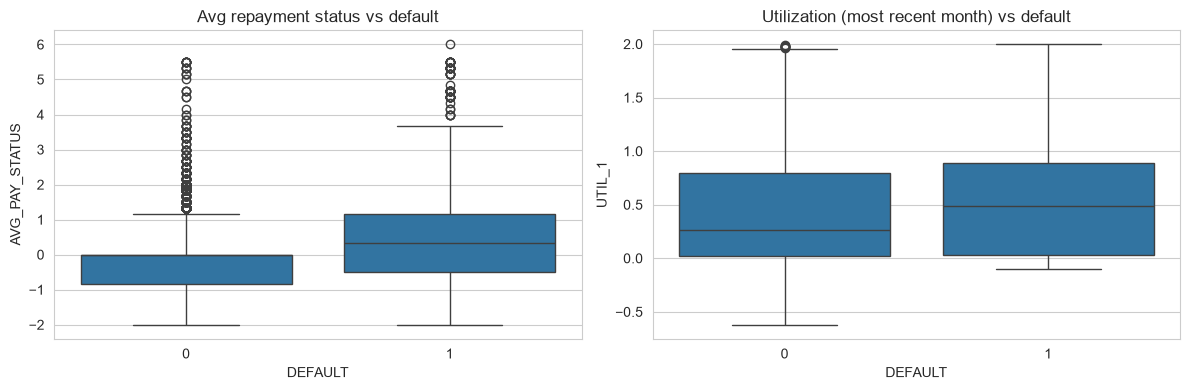

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='DEFAULT', y='AVG_PAY_STATUS', data=fe, ax=axes[0])
axes[0].set_title('Avg repayment status vs default')
sns.boxplot(x='DEFAULT', y='UTIL_1', data=fe[fe['UTIL_1'].between(-1, 2)], ax=axes[1])
axes[1].set_title('Utilization (most recent month) vs default')
plt.tight_layout()
plt.show()


Both show a clear separation — clients who default tend to run a higher (more delinquent)
average repayment status and a higher current utilization ratio. That matches how a bank
credit officer would reason about risk, and gives us some confidence these features will
help the models.

## 5. Train / Test Split

Same approach as in class: hold out 20% of the data purely for evaluation, stratified on the
target so both splits keep the same ~22% default rate.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)


(24000, 34) (6000, 34)


## 6. Model 1: Logistic Regression

**Why this model fits the business problem.** Logistic Regression is a natural first choice
for a bank because it's directly interpretable: each coefficient shows how a one-unit change
in a feature (say, utilization) shifts a client's odds of default, in either direction. A
risk team can look at the fitted model and explain *why* a client was flagged — which matters
for both internal review and, in many jurisdictions, regulatory requirements around
explainable credit decisions. It also outputs a probability rather than just a label, which
lets the bank rank customers by risk rather than treat everyone above the line identically.

As covered in class, Logistic Regression is sensitive to the scale of its inputs (a feature
like `LIMIT_BAL`, in the hundreds of thousands, would otherwise dominate a feature like
`NUM_MONTHS_DELAYED`, which only ranges 0-6), so we standardize with `StandardScaler` before
fitting, fitting the scaler on the training data only and applying it to the test data.


In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)
y_prob_lr = logreg.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))


Accuracy: 0.8075


Precision: 0.6423841059602649
Recall: 0.292388847023361
F1: 0.4018643190056965
ROC-AUC: 0.7442088632753923


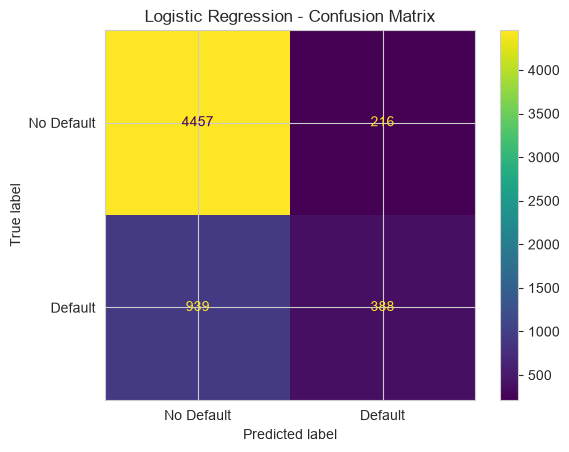

In [10]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=['No Default', 'Default'])
plt.title('Logistic Regression - Confusion Matrix')
plt.show()


## 7. Model 2: Decision Tree

**Why this model fits the business problem.** A Decision Tree offers something Logistic
Regression can't as naturally: it captures non-linear rules and interactions, like "IF
`AVG_PAY_STATUS` is high AND `UTIL_1` is high THEN high risk," without us having to manually
build interaction terms. It also produces a set of if/then rules that map onto how a credit
analyst might actually reason through a case, and it needs no feature scaling since splits
are based on thresholds, not magnitudes.

As covered in class with the wine-quality tree, we tune `max_depth`, `min_samples_split`, and
`min_samples_leaf` with `GridSearchCV` rather than picking them by hand — an untuned tree
tends to overfit the training data (memorizing individual clients) and generalize poorly to
new applicants, so cross-validated tuning matters here just as it did in the class example.


In [11]:
param_grid = {
    'max_depth': [3, 4, 5, 6, 8, 10],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy'],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)


Best params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 50}
Best CV ROC-AUC: 0.7740140546271342


In [12]:
tree_clf = grid_search.best_estimator_

y_pred_dt = tree_clf.predict(X_test)
y_prob_dt = tree_clf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))


Accuracy: 0.8196666666666667
Precision: 0.6510480887792849
Recall: 0.39788997739261495
F1: 0.4939195509822264
ROC-AUC: 0.7666436975161226


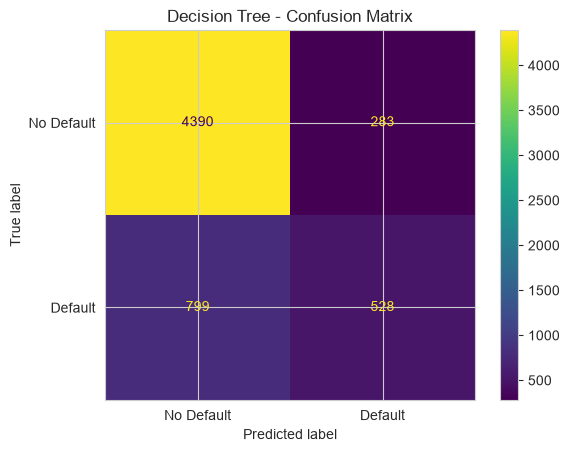

In [13]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, display_labels=['No Default', 'Default'])
plt.title('Decision Tree - Confusion Matrix')
plt.show()


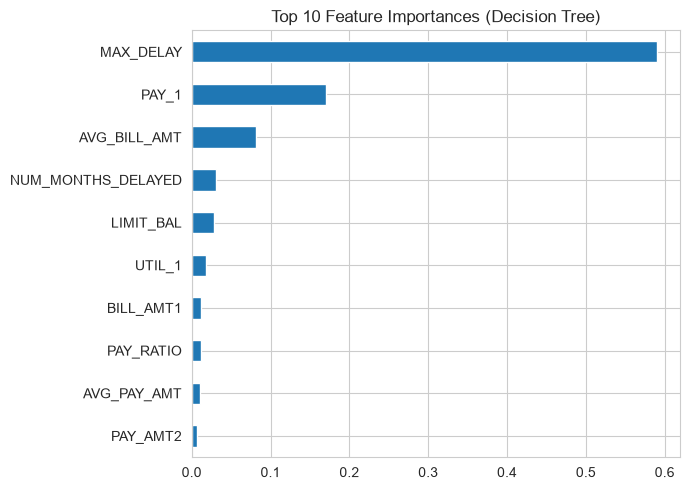

In [14]:
# Which features does the tree rely on most? Same feature_importances_ inspection
# we did on the wine dataset in class.
importances = pd.Series(tree_clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances.head(10).plot(kind='barh', figsize=(7, 5))
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances (Decision Tree)')
plt.tight_layout()
plt.show()


The tree leans most heavily on `MAX_DELAY` (the worst repayment delay seen over the 6-month
window) and `PAY_1` (the most recent month's repayment status), with the engineered
`AVG_BILL_AMT` and `NUM_MONTHS_DELAYED` also in the top 5 — these are the same repayment-history
signals a real credit analyst would check first, which is a good sign the model is picking
up genuine risk signal rather than noise.

In [15]:
importances_table = importances.head(10)
importances_table


MAX_DELAY             0.589862
PAY_1                 0.170760
AVG_BILL_AMT          0.081091
NUM_MONTHS_DELAYED    0.030619
LIMIT_BAL             0.028503
UTIL_1                0.018532
BILL_AMT1             0.012353
PAY_RATIO             0.012054
AVG_PAY_AMT           0.010053
PAY_AMT2              0.007256
dtype: float64

## 8. Does Feature Engineering Actually Help?

The eight engineered features from Section 3 (`UTIL_1`, `AVG_BILL_AMT`, `AVG_PAY_AMT`,
`AVG_PAY_STATUS`, `MAX_DELAY`, `NUM_MONTHS_DELAYED`, `BILL_CHANGE`, `PAY_RATIO`) are built
entirely out of the raw monthly columns, so it's worth directly checking whether they add
information a model couldn't already get from the raw columns on their own. We re-run the
exact same tuning procedure (`GridSearchCV` over the same `param_grid`, same train/test
split) on a version of the data with the engineered columns removed, and compare ROC-AUC
against the full-feature Decision Tree above.


In [16]:
engineered_cols = ['UTIL_1', 'AVG_BILL_AMT', 'AVG_PAY_AMT', 'AVG_PAY_STATUS',
                    'MAX_DELAY', 'NUM_MONTHS_DELAYED', 'BILL_CHANGE', 'PAY_RATIO']

X_train_raw = X_train.drop(columns=engineered_cols)
X_test_raw = X_test.drop(columns=engineered_cols)

grid_search_raw = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
)
grid_search_raw.fit(X_train_raw, y_train)

tree_raw = grid_search_raw.best_estimator_
y_prob_dt_raw = tree_raw.predict_proba(X_test_raw)[:, 1]

print("Decision Tree ROC-AUC, raw features only:       ", round(roc_auc_score(y_test, y_prob_dt_raw), 4))
print("Decision Tree ROC-AUC, with engineered features:", round(roc_auc_score(y_test, y_prob_dt), 4))


Decision Tree ROC-AUC, raw features only:        0.7541
Decision Tree ROC-AUC, with engineered features: 0.7666


## 9. Model Comparison

We compare both models on the same metrics: accuracy, precision, recall, F1, and ROC-AUC. For
a defaults problem, **recall on the default class matters most** from a business standpoint —
a missed defaulter (false negative) usually costs the bank far more (unpaid balance, collections
cost) than a false positive (an unnecessarily flagged good customer, who can simply be
reviewed manually and still gets their credit approved after a second look).


In [17]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_dt)],
    'Precision (Default)': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_dt)],
    'Recall (Default)': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_dt)],
    'F1 (Default)': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_dt)],
    'ROC-AUC': [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_dt)],
})
results


,Model,Accuracy,Precision (Default),Recall (Default),F1 (Default),ROC-AUC
0,Logistic Regression,0.807500,0.642384,0.292389,0.401864,0.744209
1,Decision Tree,0.819667,0.651048,0.397890,0.493920,0.766644


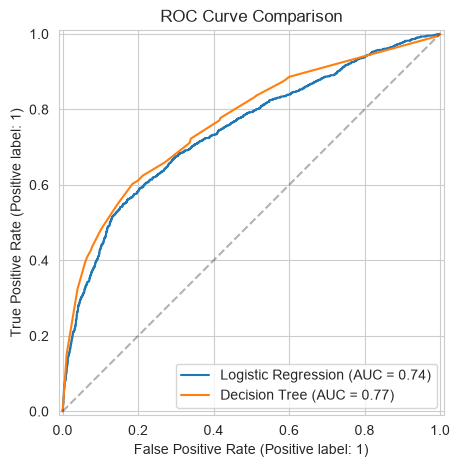

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_lr, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_dt, name='Decision Tree', ax=ax)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_title('ROC Curve Comparison')
plt.show()


## 10. Precision-Recall Tradeoff

Both models default to a 0.5 probability threshold for classifying someone as "will
default," but that threshold isn't a law of nature — it's a business choice. If missing a
defaulter is costlier than a false alarm, the bank may want to **lower** the threshold to
catch more defaulters, accepting more false positives in exchange. The precision-recall
curve, which we used in class to look at exactly this tradeoff, lets us see that
relationship directly rather than committing to a single fixed threshold.


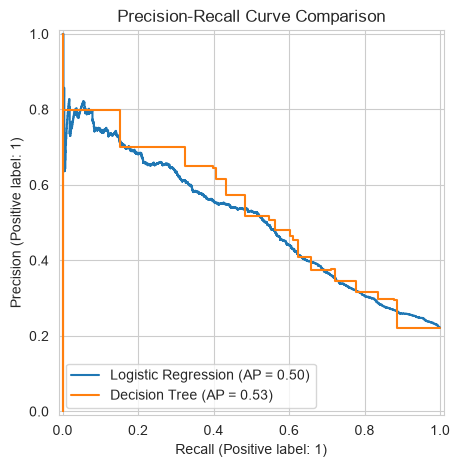

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_prob_lr, name='Logistic Regression', ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_prob_dt, name='Decision Tree', ax=ax)
ax.set_title('Precision-Recall Curve Comparison')
plt.show()


## 11. Conclusion

Both models land in a similar range on accuracy, but the Decision Tree edges out Logistic
Regression on ROC-AUC and on recall for the default class — meaning it catches more true
defaulters, which is the error a bank cares about avoiding most. It also mirrors how a credit
analyst actually reasons ("if repayment history is bad AND utilization is high, flag this
account"), which makes it easier to explain a specific decision to a loan officer or an
applicant than the Logistic Regression's coefficient-based explanation.

Logistic Regression's advantage is nuance: because it returns smoothly-varying probabilities
driven by clear coefficients, it's easier to justify individual scores for regulatory
purposes and integrates cleanly with a business rule like "flag anyone above 40% predicted
default probability," which is exactly the kind of threshold decision the precision-recall
curve above supports.

**Given the emphasis on catching likely defaulters (recall) without sacrificing much
accuracy or interpretability, the Decision Tree is selected as the primary model**, with
Logistic Regression kept as a secondary, more transparent model that could be used
alongside it for cases that need a clear, regulator-friendly explanation. As with any
threshold-based classifier, the bank should tune the decision threshold (rather than
leaving it at the default 0.5) based on its actual cost of a missed default versus a false
alarm, using the precision-recall curve above as a guide.
